In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from mlxtend.plotting import plot_decision_regions

import struct

sns.set_theme()

In [147]:
df = sns.load_dataset('titanic').drop(columns=["deck", "class", "embark_town", "alive"])
df['sex'] = df['sex'].replace({'male': 0, "female": 1})

df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna(how = "any")

# now one hot encode a few cols
df['embarked_S'] = (df['embarked'] == "S").astype(np.int64)
df['embarked_C'] = (df['embarked'] == "C").astype(np.int64)
df['embarked_Q'] = (df['embarked'] == "Q").astype(np.int64)
df['is_man'] = (df['who'] == 'man').astype(np.int64)
df['is_woman'] = (df['who'] == 'woman').astype(np.int64)
df['is_child'] = (df['who'] == 'child').astype(np.int64)
df['adult_male'] = df['adult_male'].astype(np.int64)
df['alone'] = df['alone'].astype(np.int64)

df = df.drop(columns=['embarked', 'who'])
df

/tmp/ipykernel_13631/2875798953.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 0, "female": 1})


,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_S,embarked_C,embarked_Q,is_man,is_woman,is_child
0,0,3,0,22.0,1,0,7.2500,1,0,1,0,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,0,0,0,1,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,0,0,1,0
3,1,1,1,35.0,1,0,53.1000,0,0,1,0,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,1,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,1,1,1,0,0,1,0,0
887,1,1,1,19.0,0,0,30.0000,0,1,1,0,0,0,1,0
888,0,3,1,28.0,1,2,23.4500,0,0,1,0,0,0,1,0
889,1,1,0,26.0,0,0,30.0000,1,1,0,1,0,1,0,0


In [148]:
train_cutoff = round(0.7 * df.shape[0])
train_X = df.iloc[:train_cutoff, 1:].to_numpy()
test_X = df.iloc[train_cutoff:, 1:].to_numpy()
train_y = df.iloc[:train_cutoff, 0].to_numpy()
test_y = df.iloc[train_cutoff:, 0].to_numpy()

In [149]:
tree = sklearn.tree.DecisionTreeClassifier(max_depth = 3)
tree.fit(train_X, train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [150]:
print(sklearn.tree.export_text(tree, feature_names=list(df)[1:]))

|--- adult_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 149.04
|   |   |   |--- class: 1
|   |   |--- fare >  149.04
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 24.81
|   |   |   |--- class: 1
|   |   |--- fare >  24.81
|   |   |   |--- class: 0
|--- adult_male >  0.50
|   |--- pclass <= 1.50
|   |   |--- age <= 49.50
|   |   |   |--- class: 0
|   |   |--- age >  49.50
|   |   |   |--- class: 0
|   |--- pclass >  1.50
|   |   |--- fare <= 7.76
|   |   |   |--- class: 0
|   |   |--- fare >  7.76
|   |   |   |--- class: 0



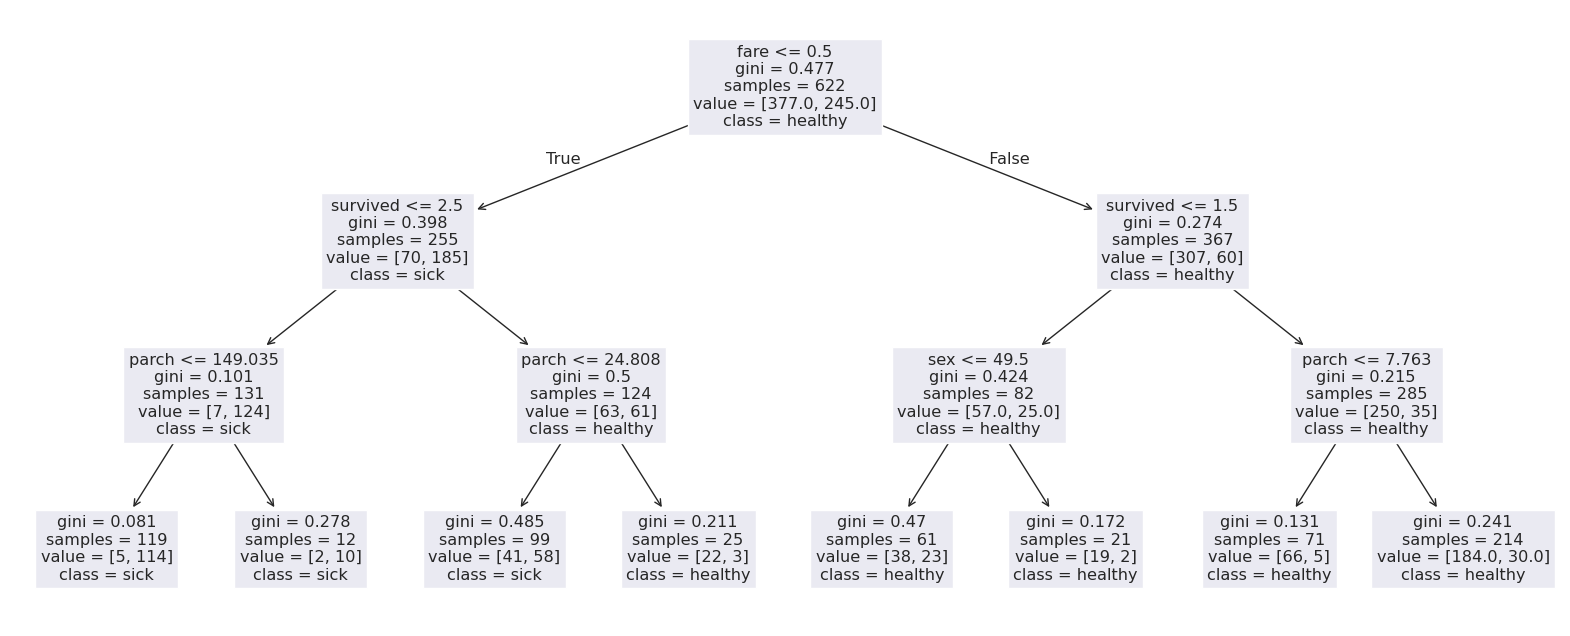

In [151]:
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(tree, feature_names=list(df)[:-1], class_names=["healthy", "sick"])
plt.show()

In [152]:
print(list(df))

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'embarked_S', 'embarked_C', 'embarked_Q', 'is_man', 'is_woman', 'is_child']


<Axes: >

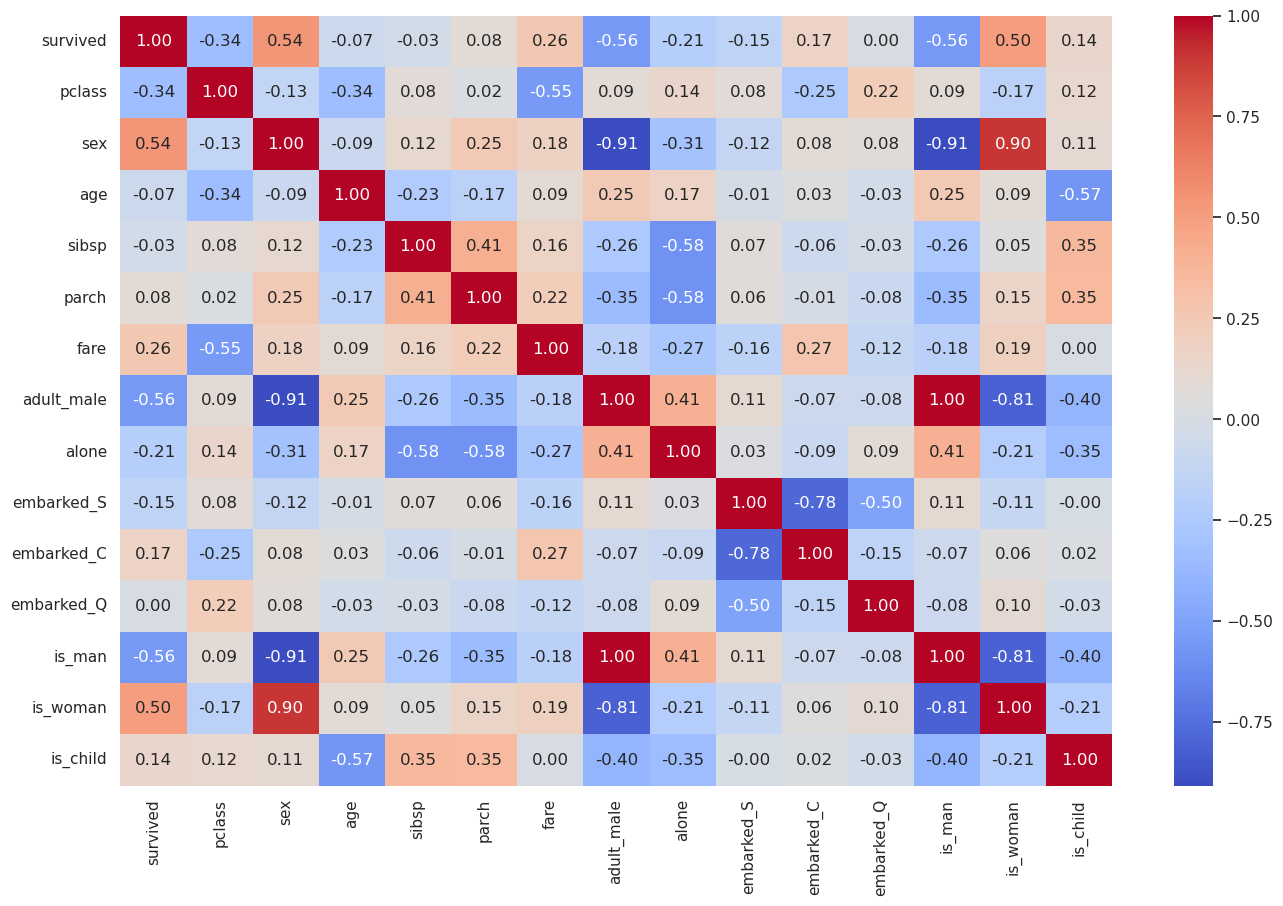

In [178]:
corr_mat = df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")

In [179]:
# feature_names = ["thalach", "cp"]
feature_names = ["sex", "fare"]

In [180]:
# repeat only with ca and thalach
train_cutoff = round(0.7 * df.shape[0])
cut_df = df[[*feature_names, "survived"]]
train_X = cut_df.iloc[:train_cutoff, :-1].to_numpy()
test_X = cut_df.iloc[train_cutoff:, :-1].to_numpy()
X = cut_df.iloc[:, :-1].to_numpy()
train_y = cut_df.iloc[:train_cutoff, -1].to_numpy()
test_y = cut_df.iloc[train_cutoff:, -1].to_numpy()
y = cut_df.iloc[:, -1].to_numpy()
train_X

array([[ 0.    ,  7.25  ],
       [ 1.    , 71.2833],
       [ 1.    ,  7.925 ],
       ...,
       [ 0.    , 14.4542],
       [ 0.    , 52.5542],
       [ 0.    , 15.7417]], shape=(622, 2))

In [188]:
tree = sklearn.tree.DecisionTreeClassifier(max_depth = 2)
tree.fit(train_X, train_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

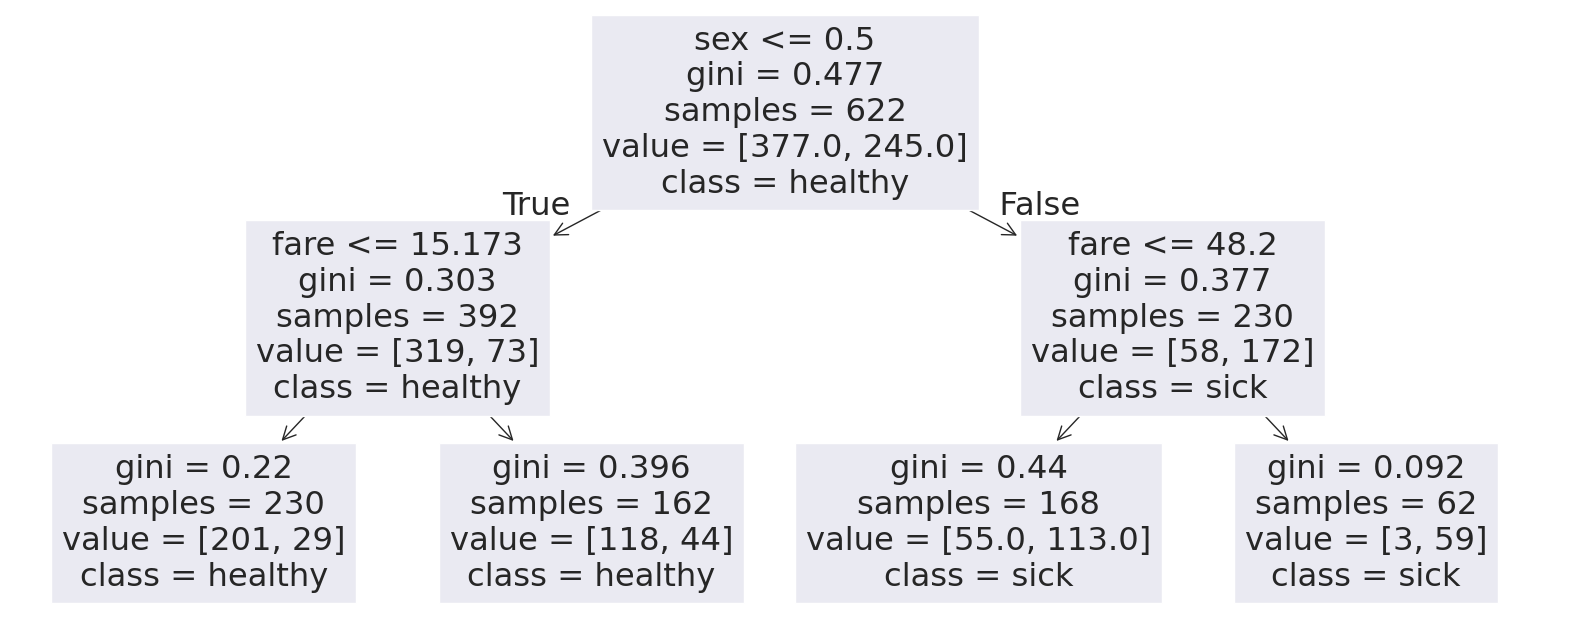

In [189]:
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(tree, feature_names=feature_names, class_names=["healthy", "sick"])
plt.show()

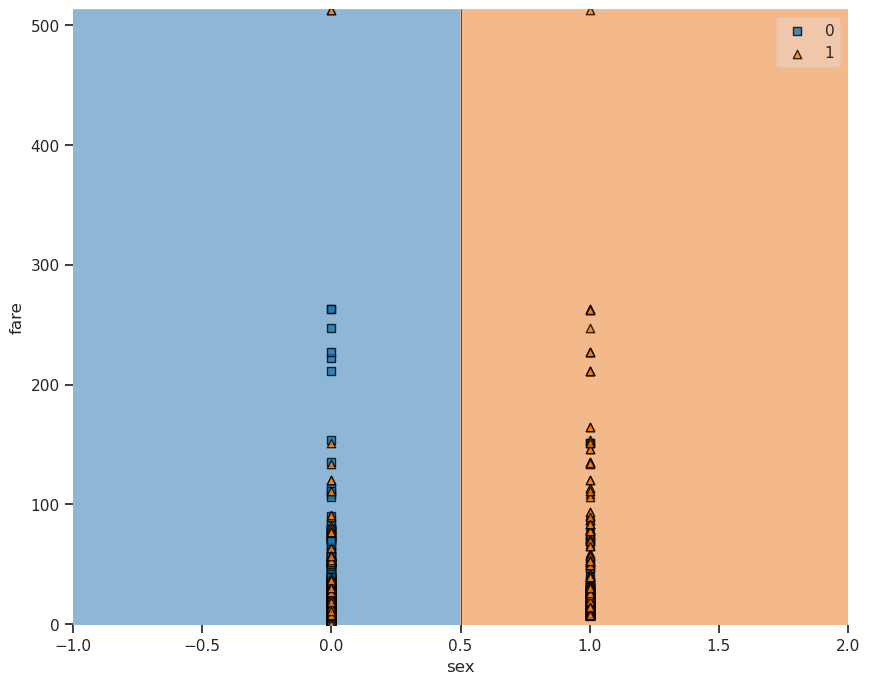

In [190]:
plt.figure(figsize = (10, 8))
plot_decision_regions(X, y.astype(np.int32), clf = tree)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.grid()


In [191]:
test_predictions = tree.predict(test_X)
confusion_matrix = sklearn.metrics.confusion_matrix(test_y, test_predictions)
conf_df = pd.DataFrame(confusion_matrix)
conf_df
accurate_count = conf_df.iloc[0, 0] + conf_df.iloc[1, 1]
inaccurate_count = conf_df.iloc[1, 0] + conf_df.iloc[0, 1]
print(accurate_count / (accurate_count + inaccurate_count))

0.7790262172284644
